C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


正在进行超参数调优，请稍候...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

最佳参数组合: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

--- 最佳模型分类报告 ---
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      3009
           1       0.79      0.94      0.86      1071

    accuracy                           0.92      4080
   macro avg       0.88      0.93      0.90      4080
weighted avg       0.93      0.92      0.92      4080

ROC-AUC Score: 0.9851


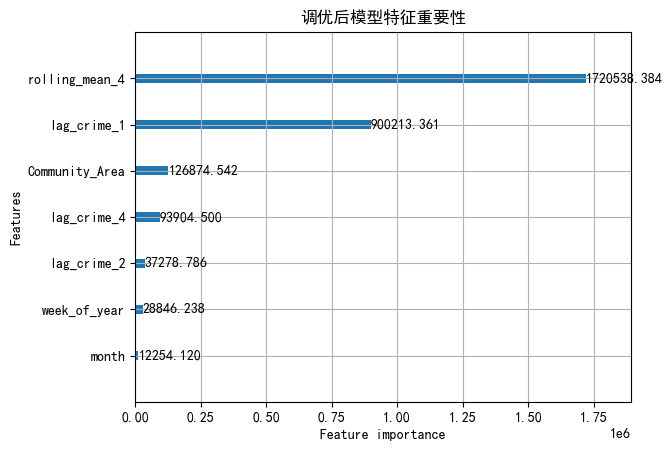

调优后的模型已成功保存为: chicago_crime_model_lightgbm_tuned.joblib


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据
path = r'C:\Users\LENOVO\Downloads\chicago_crime_2015_2024_enriched.parquet'
df = pd.read_parquet(path)

# 2. 数据转换
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = df['Date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_crime = df.groupby(['Week', 'Community Area']).size().reset_index(name='crime_count')

# 3. 标签定义
weekly_crime['is_high_risk'] = weekly_crime.groupby('Week')['crime_count'].transform(
    lambda x: (x >= x.quantile(0.75)).astype(int)
)

# 4. 特征工程
weekly_crime = weekly_crime.sort_values(['Community Area', 'Week'])
for i in [1, 2, 4]:
    weekly_crime[f'lag_crime_{i}'] = weekly_crime.groupby('Community Area')['crime_count'].shift(i)

weekly_crime['rolling_mean_4'] = weekly_crime.groupby('Community Area')['crime_count'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)
weekly_crime['month'] = weekly_crime['Week'].dt.month
weekly_crime['week_of_year'] = weekly_crime['Week'].dt.isocalendar().week.astype(int)
weekly_crime = weekly_crime.dropna()

# 5. 划分训练集和测试集
train = weekly_crime[weekly_crime['Week'] < '2024-01-01']
test = weekly_crime[weekly_crime['Week'] >= '2024-01-01']

features = ['Community Area', 'lag_crime_1', 'lag_crime_2', 'lag_crime_4', 'rolling_mean_4', 'month', 'week_of_year']
target = 'is_high_risk'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# ==========================================
# 6. 新增：超参数调优 (Randomized Search)
# ==========================================
print("正在进行超参数调优，请稍候...")

# 定义搜索空间
param_dist = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 100],
    'max_depth': [-1, 10, 20], # -1 表示不限制深度
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

# 初始化基础模型
lgb_model = lgb.LGBMClassifier(is_unbalance=True, importance_type='gain', verbosity=-1)

# 配置随机搜索
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=10,      # 尝试10组随机组合，如果时间充裕可以改为20
    scoring='roc_auc',
    cv=3,           # 3折交叉验证
    verbose=1,
    n_jobs=-1,      # 使用全部 CPU 核心
    random_state=42
)

# 执行搜索
random_search.fit(X_train, y_train)

# 获取最佳模型
clf = random_search.best_estimator_
print(f"\n最佳参数组合: {random_search.best_params_}")

# ==========================================
# 7. 性能测试 (使用调优后的最佳模型)
# ==========================================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\n--- 最佳模型分类报告 ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 8. 特征重要性分析
lgb.plot_importance(clf, max_num_features=10, title="调优后模型特征重要性")
plt.show()

# 9. 模型保存 (修复了变量名错误)
model_filename = 'chicago_crime_model_lightgbm_tuned.joblib'
joblib.dump(clf, model_filename)

print(f"调优后的模型已成功保存为: {model_filename}")

正在进行 XGBoost 超参数调优...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


D:\anaconda\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Optimal parameter combination: {'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

--- Optimized XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      3009
           1       0.76      0.96      0.85      1071

    accuracy                           0.91      4080
   macro avg       0.87      0.93      0.89      4080
weighted avg       0.93      0.91      0.91      4080

XGBoost ROC-AUC Score: 0.9862


<Figure size 1000x600 with 0 Axes>

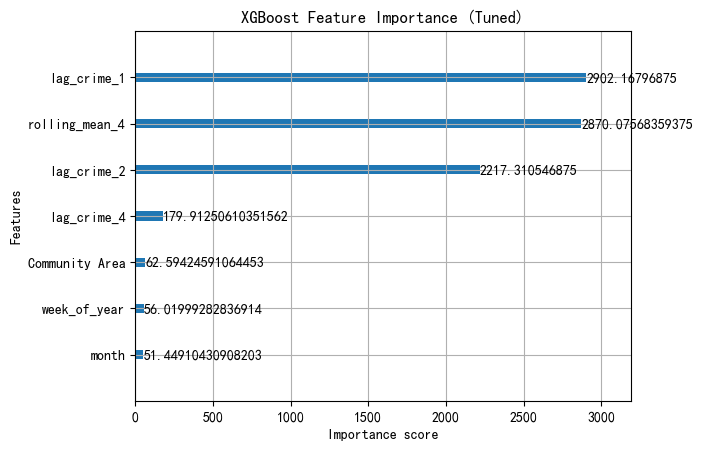

The optimized model has been successfully saved as: chicago_crime_model_xgboost_tuned.joblib


In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 解决绘图中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 1. 加载数据
path = r'C:\Users\LENOVO\Downloads\chicago_crime_2015_2024_enriched.parquet'
df = pd.read_parquet(path)

# 2. 数据转换
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = df['Date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_crime = df.groupby(['Week', 'Community Area']).size().reset_index(name='crime_count')

# 3. 标签定义
weekly_crime['is_high_risk'] = weekly_crime.groupby('Week')['crime_count'].transform(
    lambda x: (x >= x.quantile(0.75)).astype(int)
)

# 4. 特征工程
weekly_crime = weekly_crime.sort_values(['Community Area', 'Week'])
for i in [1, 2, 4]:
    weekly_crime[f'lag_crime_{i}'] = weekly_crime.groupby('Community Area')['crime_count'].shift(i)

weekly_crime['rolling_mean_4'] = weekly_crime.groupby('Community Area')['crime_count'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)
weekly_crime['month'] = weekly_crime['Week'].dt.month
weekly_crime['week_of_year'] = weekly_crime['Week'].dt.isocalendar().week.astype(int)
weekly_crime = weekly_crime.dropna()

# 5. 划分数据集
train = weekly_crime[weekly_crime['Week'] < '2024-01-01']
test = weekly_crime[weekly_crime['Week'] >= '2024-01-01']

features = ['Community Area', 'lag_crime_1', 'lag_crime_2', 'lag_crime_4', 'rolling_mean_4', 'month', 'week_of_year']
target = 'is_high_risk'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 计算正负样本比例
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# ==========================================
# 6. XGBoost 超参数随机搜索
# ==========================================
print("正在进行 XGBoost 超参数调优...")

param_dist = {
    'n_estimators': [500, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# 【关键点】：在初始化时定义 early_stopping_rounds，处理类别不平衡用 scale_pos_weight
base_xgb = xgb.XGBClassifier(
    tree_method='hist', 
    eval_metric='auc',
    early_stopping_rounds=50,  # 新版规范：放在初始化这里
    scale_pos_weight=ratio,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# 搜索时需要 eval_set 来触发早停逻辑
random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 获取最佳模型
model_xgb = random_search.best_estimator_
print(f"\nOptimal parameter combination: {random_search.best_params_}")

# ==========================================
# 7. 验证最佳模型 (无需重复 fit)
# ==========================================
# 提示：random_search.best_estimator_ 已经是调优并训练好的模型。
# 直接使用它进行预测即可。

# 8. 性能测试
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

print("\n--- Optimized XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 9. 特征重要性
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, max_num_features=10, importance_type='gain')
plt.title("XGBoost Feature Importance (Tuned)")
plt.show()

# 10. 保存模型
model_filename = 'chicago_crime_model_xgboost_tuned.joblib'
joblib.dump(model_xgb, model_filename)

print(f"The optimized model has been successfully saved as: {model_filename}")